In [4]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
np.random.seed(42)  # for reproducibility

n_students = 1000

data = {
    "Student_ID": range(1, n_students + 1),
    
    "Age": np.random.randint(17, 25, n_students),
    
    "Attendance_Percentage": np.random.normal(80, 15, n_students),
    
    "Study_Hours_Per_Week": np.random.gamma(shape=2, scale=5, size=n_students),
    
    "Internal_Assessment": np.random.normal(70, 10, n_students),
    
    "Exam_Score": np.random.normal(75, 12, n_students)
}

df = pd.DataFrame(data)


Introducing missing values (there are 5% of missing values in each variable)

In [7]:
for col in df.columns[1:]:
    df.loc[df.sample(frac=0.05).index, col] = np.nan


In [8]:
# Invalid attendance values
df.loc[df.sample(10).index, 'Attendance_Percentage'] = [120, -10, 150, 200, -20, 130, 140, -5, 110, 160]

# Extreme study hours
df.loc[df.sample(10).index, 'Study_Hours_Per_Week'] = [0, 60, 70, 80, 90, 100, 65, 75, 85, 95]

# Unrealistic ages
df.loc[df.sample(5).index, 'Age'] = [5, 60, 45, 3, 70]


In [9]:
df.head()

,Student_ID,Age,Attendance_Percentage,Study_Hours_Per_Week,Internal_Assessment,Exam_Score
0,1,23.0,85.126340,19.876669,77.574951,55.289360
1,2,20.0,108.142563,23.022863,61.917816,88.103354
2,3,21.0,94.256358,11.669024,77.099291,85.841266
3,4,23.0,71.346445,4.679546,80.728867,98.860008
4,5,19.0,66.523780,6.190632,73.254369,102.365992


In [10]:
df.shape

(1000, 6)

In [11]:
df.to_csv("academic_performance_large_dataset.csv", index=False)

In [31]:
df.describe()

,Student_ID,Age,Attendance_Percentage,Study_Hours_Per_Week,Internal_Assessment,Exam_Score
count,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000
mean,500.594378,20.552209,80.732669,9.924206,69.975794,74.885476
std,288.861268,3.206821,16.945962,6.359742,9.695246,11.238290
min,1.000000,3.000000,-20.000000,0.000000,41.001062,41.046614
25%,250.750000,19.000000,70.556419,5.060487,63.895939,67.488165
50%,499.500000,20.000000,80.707844,8.527014,69.669829,74.810761
75%,750.250000,22.000000,90.481174,13.140098,76.209411,82.171185
max,1000.000000,70.000000,200.000000,25.285339,97.659796,108.226708


checking the missing values

In [12]:
df.isnull().sum()

Student_ID                0
Age                      50
Attendance_Percentage    50
Study_Hours_Per_Week     50
Internal_Assessment      50
Exam_Score               50
dtype: int64

Mean works well when data is approximately symmetric. Mean imputation was used for approximately symmetric numerical data, as it preserves the central tendency of the dataset.

In [13]:
df['Exam_Score'] = df['Exam_Score'].fillna(df['Exam_Score'].mean())

In [14]:
df.isnull().sum()


Student_ID                0
Age                      50
Attendance_Percentage    50
Study_Hours_Per_Week     50
Internal_Assessment      50
Exam_Score                0
dtype: int64

Median imputation was applied to variables affected by extreme values, as it provides a robust measure of central tendency.

In [15]:
df['Study_Hours_Per_Week'] = df['Study_Hours_Per_Week'].fillna(
    df['Study_Hours_Per_Week'].median()
)


Age has repeated values → mode is suitable. 

In [16]:
df['Age'] = df['Age'].fillna(df['Age'].mode()[0])


Attendance can be assumed similar to nearby records. It makes use of ffill() method which is forward fill in this it fill NaN with the last valid non missing number and does same untill next valid number.

In [18]:
df['Attendance_Percentage'] = df['Attendance_Percentage'].ffill()

In [19]:
df.isnull().sum()

Student_ID                0
Age                       0
Attendance_Percentage     0
Study_Hours_Per_Week      0
Internal_Assessment      50
Exam_Score                0
dtype: int64

In [20]:
df['Internal_Assessment'] = df['Intern.0al_Assessment'].fillna(
    df['Internal_Assessment'].median()
)

In [21]:
df.isnull().sum()

Student_ID               0
Age                      0
Attendance_Percentage    0
Study_Hours_Per_Week     0
Internal_Assessment      0
Exam_Score               0
dtype: int64

imports Matplotlib's for creating visualization plt is alias 

Points outside whiskers are outliers. Box plots were used to identify potential outliers, where points outside the whiskers indicate extreme values.

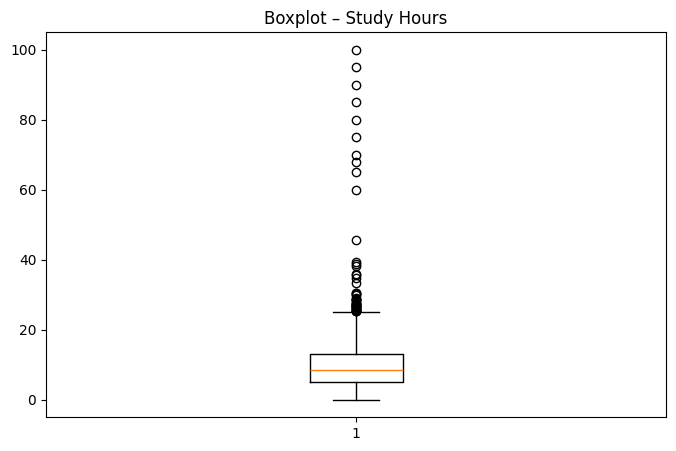

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df['Study_Hours_Per_Week'])
plt.title("Boxplot – Study Hours")
plt.show()


Isolated points far from cluster indicate outliers. Scatters plots are especially useful when to see the distribution of individual points.

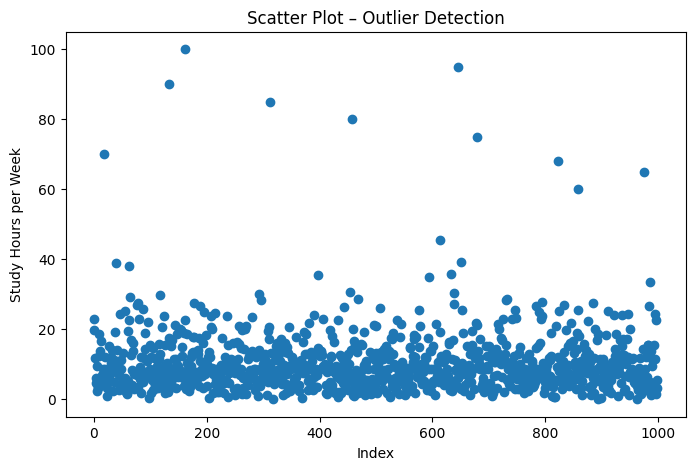

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(df.index, df['Study_Hours_Per_Week'])
plt.xlabel("Index")
plt.ylabel("Study Hours per Week")
plt.title("Scatter Plot – Outlier Detection")
plt.show()


Outlier Detection Method Used.

Z-score identifies values far from mean (>3σ). if Z > 3 the value is consisdered as an outlier. scipy.stats is a python lib that contains a lot of statistical functions , mainly Z-score function which is often used for detecting the ouliers. this meathod is to be used when data is normally distributed here for study purpose used.

In [24]:
from scipy import stats

df['Z_score'] = stats.zscore(df['Exam_Score'])
outliers_z = df[abs(df['Z_score']) > 3]
outliers_z


,Student_ID,Age,Attendance_Percentage,Study_Hours_Per_Week,Internal_Assessment,Exam_Score,Z_score
29,30,20.0,68.772702,7.300447,59.323651,40.146427,-3.027522
525,526,23.0,83.287255,0.729449,57.665024,37.803954,-3.232110
561,562,19.0,69.621379,14.744776,59.436720,35.699872,-3.415877
789,790,23.0,75.789874,24.883104,69.669829,111.176541,3.176124


Q1 are used to calculate 25% of data lies in from dataframe and Q3 tells where 75 lies in range, IQR measures the spread of the middle 50% of the data. lower and upper bounds are calculated for finding the outliers the students who studies more or less then IOR range avoid using this when there are meaningful data like exceptional students. This method is best suited for this method because of distributed skewed data and missing values.

In [39]:
Q1 = df['Study_Hours_Per_Week'].quantile(0.25)
Q3 = df['Study_Hours_Per_Week'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df[(df['Study_Hours_Per_Week'] < lower_bound) | 
   (df['Study_Hours_Per_Week'] > upper_bound)]


,Student_ID,Age,Attendance_Percentage,Study_Hours_Per_Week,Internal_Assessment,Exam_Score,Log_Study_Hours
18,19,24.0,73.249018,25.285339,61.297438,52.077457,3.269011
40,41,19.0,65.526148,25.285339,69.669829,64.173715,3.269011
62,63,21.0,72.291996,25.285339,61.582881,61.674891,3.269011
64,65,23.0,79.059814,25.285339,54.111815,93.351650,3.269011
76,77,20.0,69.504117,25.285339,53.673973,61.557799,3.269011
79,80,70.0,76.685456,25.285339,62.077016,70.413273,3.269011
87,88,17.0,100.503114,25.285339,69.998809,74.810761,3.269011
118,119,24.0,70.240361,25.285339,60.797615,86.463886,3.269011
133,134,21.0,91.270807,25.285339,69.119555,70.078485,3.269011
162,163,24.0,85.567188,25.285339,63.189448,73.206822,3.269011


Above results are the filters that show DataFrame to show only the outliers.

Outlier Treatment Techniques

Trimming removes noise completely.

In [26]:
df_trimmed = df[
    (df['Study_Hours_Per_Week'] >= lower_bound) &
    (df['Study_Hours_Per_Week'] <= upper_bound)
]

Preserves dataset size while reducing effect of outliers. Trimming was chosen over capping to completely eliminate noise and maintain data integrity without altering original values. in this assignment is method (trimmnig) is more preferred as outlier removal does impact large loss and they are noise in dataset.

In [27]:
df['Study_Hours_Per_Week'] = np.where(
    df['Study_Hours_Per_Week'] > upper_bound,
    upper_bound,
    np.where(df['Study_Hours_Per_Week'] < lower_bound,
             lower_bound,
             df['Study_Hours_Per_Week'])
)


in capping the data is altered data that are outliers are altered with extreme low bounds or extreme high bounds this method is used when data is small and outliers are meaningful
in this assignment outliers are treated as noise so this method is less prefered.

In [28]:
df = df[abs(df['Z_score']) <= 3]
df = df.drop(columns=['Z_score'])


Outliers were removed using the Z-score method by retaining observations whose Z-scores lie within ±3 standard deviations from the mean. This approach is based on the assumption of normal distribution, where values beyond this range are considered extreme. After filtering, the auxiliary Z-score column was removed to maintain dataset cleanliness.

Removes statistically extreme observations.

In [29]:
df.describe()

,Student_ID,Age,Attendance_Percentage,Study_Hours_Per_Week,Internal_Assessment,Exam_Score
count,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000
mean,500.594378,20.552209,80.732669,9.924206,69.975794,74.885476
std,288.861268,3.206821,16.945962,6.359742,9.695246,11.238290
min,1.000000,3.000000,-20.000000,0.000000,41.001062,41.046614
25%,250.750000,19.000000,70.556419,5.060487,63.895939,67.488165
50%,499.500000,20.000000,80.707844,8.527014,69.669829,74.810761
75%,750.250000,22.000000,90.481174,13.140098,76.209411,82.171185
max,1000.000000,70.000000,200.000000,25.285339,97.659796,108.226708


In [30]:
df.isnull().sum()

Student_ID               0
Age                      0
Attendance_Percentage    0
Study_Hours_Per_Week     0
Internal_Assessment      0
Exam_Score               0
dtype: int64

a log transformation is applied to
decrease skewness and make the distribution closer to normal

In [37]:
df['Study_Hours_Per_Week'].skew()

np.float64(0.8564594573378861)

Skewness value is positive, indicating a right-skewed distribution.

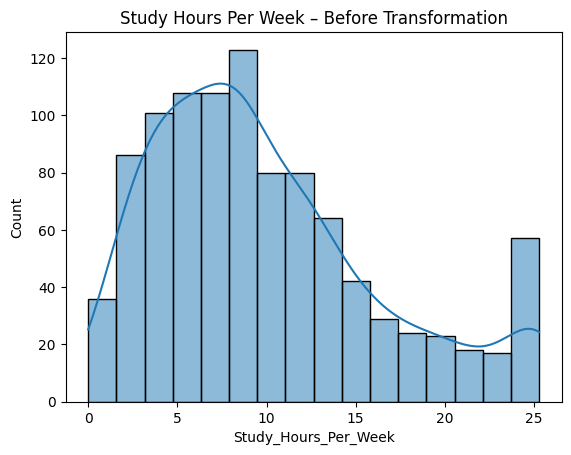

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Study_Hours_Per_Week'], kde=True)
plt.title("Study Hours Per Week – Before Transformation")
plt.show()


log1p() is used to safely handle zero values. use this method only when data is positively skewed and not negatively.
A histogram with a kernel density estimate (KDE) was plotted for the variable Study_Hours_Per_Week to examine its distribution before transformation. This visualization helps in identifying skewness, spread, and potential outliers, thereby guiding further preprocessing decisions.

In [34]:
df['Log_Study_Hours'] = np.log1p(df['Study_Hours_Per_Week'])

In [35]:
df['Log_Study_Hours'].skew()

np.float64(-0.47162816363888743)

Skewness is significantly reduced, indicating a more symmetric distribution.

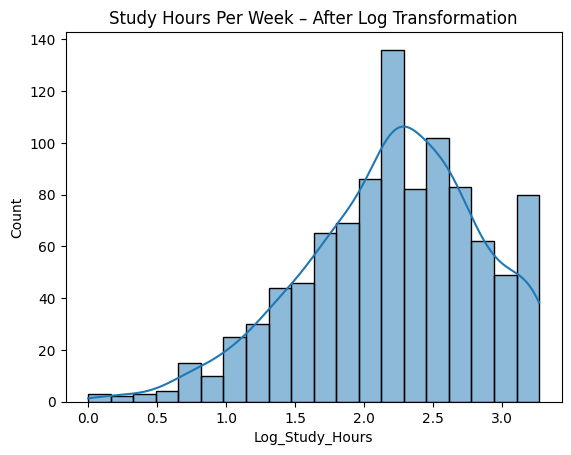

In [36]:
sns.histplot(df['Log_Study_Hours'], kde=True)
plt.title("Study Hours Per Week – After Log Transformation")
plt.show()

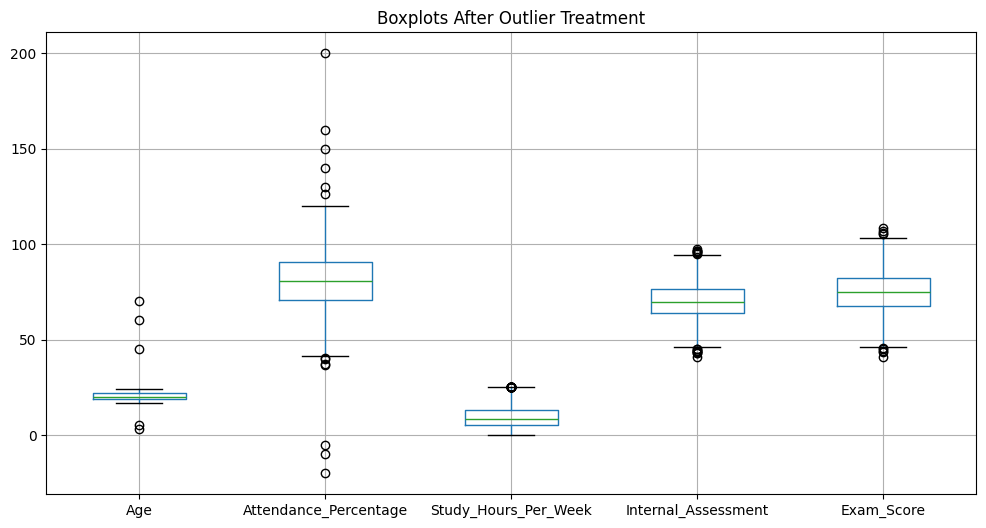

In [38]:
import matplotlib.pyplot as plt

numeric_cols = ['Age', 'Attendance_Percentage', 'Study_Hours_Per_Week', 
                'Internal_Assessment', 'Exam_Score']

plt.figure(figsize=(12,6))
df[numeric_cols].boxplot()
plt.title("Boxplots After Outlier Treatment")
plt.show()


Boxplots are the most intuitive way to see outliers. If you capped or removed outliers, the boxplots should no longer show extreme points beyond whiskers.

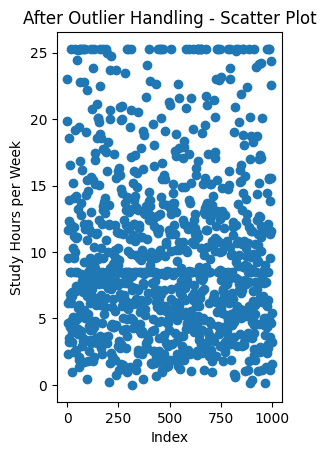

In [40]:
plt.subplot(1,2,2)
plt.scatter(df.index, df['Study_Hours_Per_Week'])
plt.xlabel("Index")
plt.ylabel("Study Hours per Week")
plt.title("After Outlier Handling - Scatter Plot")

plt.show()